In [6]:
%pip install -q pandas networkx matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [7]:
%matplotlib inline

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from graph_utils import build_type_specific_graphs, calculate_graph_metrics, load_merged_graph_inputs, visualize_graph

# Load the merged CSVs from the workspace root.
nodes, edges = load_merged_graph_inputs()

# Deduplicate nodes by id while keeping the first row for each node.
nodes = nodes.drop_duplicates(subset=["id"]).reset_index(drop=True)

# Deduplicate edges by source/target while keeping the first row for each edge.
edges = edges.drop_duplicates(subset=["source", "target"]).reset_index(drop=True)

# Keep only rows with a valid source and target.
edges = edges.dropna(subset=["source", "target"]).copy()

print(f"Loaded {len(nodes)} unique nodes and {len(edges)} unique edges")

Loaded 4002 unique nodes and 5127 unique edges


Company: 462 nodes, 507 edges
  density=0.002, avg_degree=2.19, components=67, largest_component=278


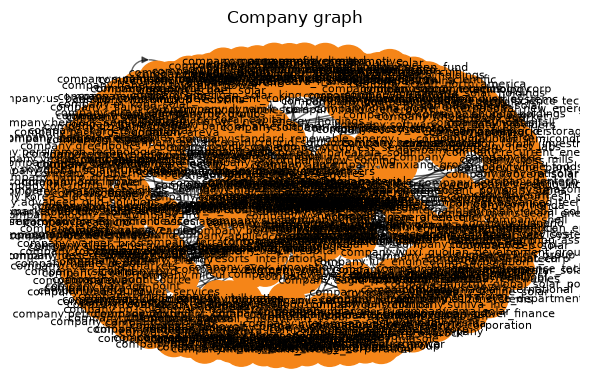

GovernmentAgency: 12 nodes, 11 edges
  density=0.083, avg_degree=1.83, components=4, largest_component=7


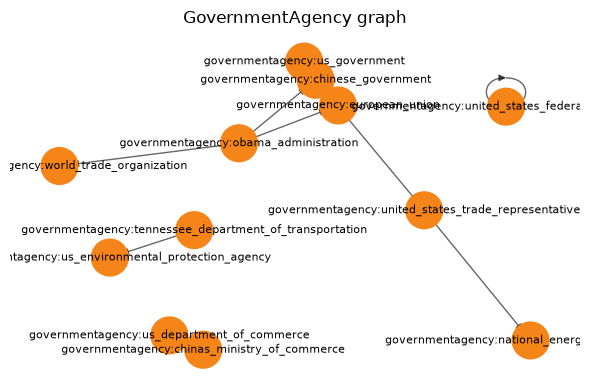

Location: 27 nodes, 24 edges
  density=0.034, avg_degree=1.78, components=10, largest_component=12


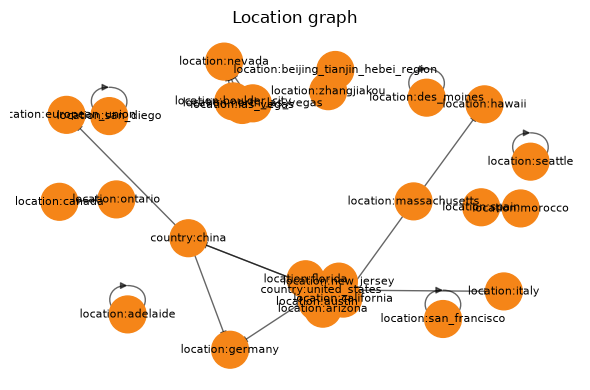

Organization: 91 nodes, 69 edges
  density=0.008, avg_degree=1.52, components=31, largest_component=9


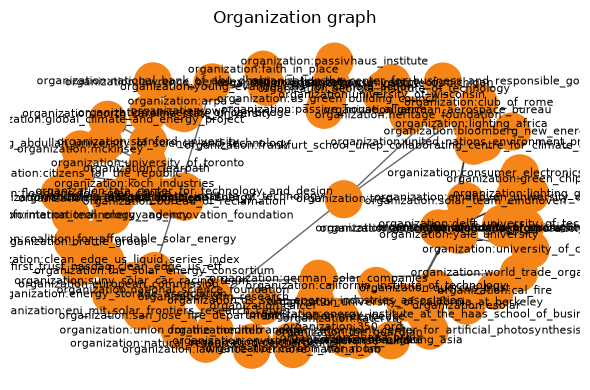

Person: 10 nodes, 6 edges
  density=0.067, avg_degree=1.20, components=4, largest_component=3


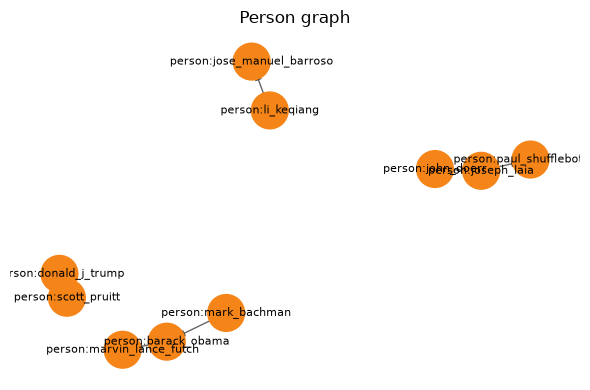

Policy: 22 nodes, 13 edges
  density=0.028, avg_degree=1.18, components=11, largest_component=3


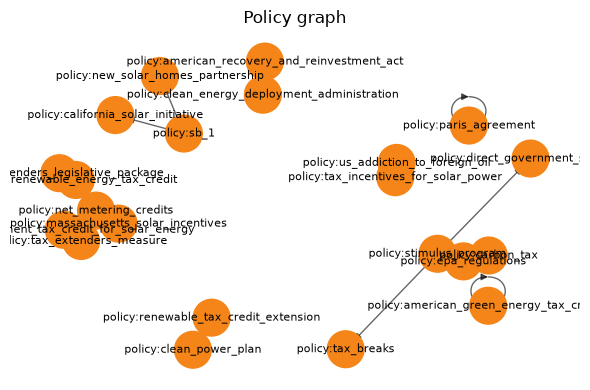

Project: 12 nodes, 7 edges
  density=0.053, avg_degree=1.17, components=7, largest_component=2


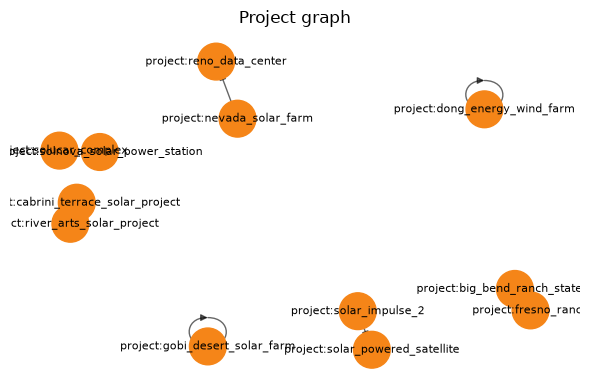

Source: 0 nodes, 0 edges
  density=0.000, avg_degree=0.00, components=0, largest_component=0


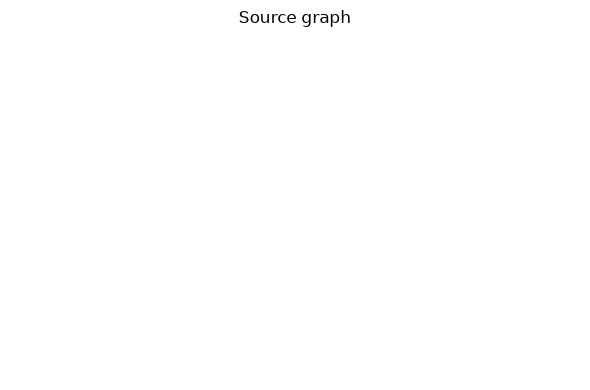

Technology: 44 nodes, 37 edges
  density=0.020, avg_degree=1.68, components=16, largest_component=14


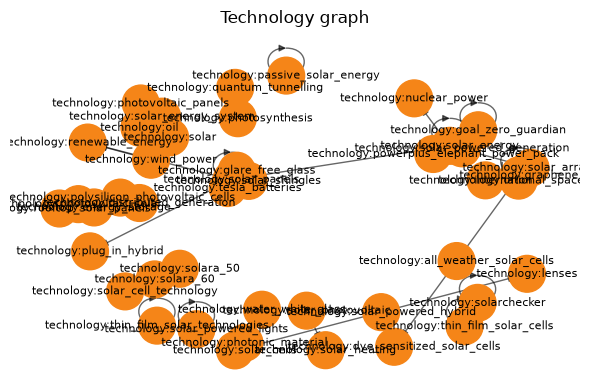

Unknown: 0 nodes, 0 edges
  density=0.000, avg_degree=0.00, components=0, largest_component=0


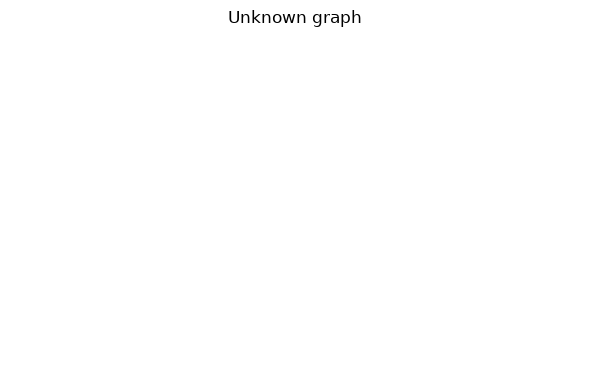

In [14]:
# Build one graph per node type, using only nodes of that type and the edges between them.
type_graphs = build_type_specific_graphs(edges, nodes=nodes, min_degree=1)

for node_type, (graph, filtered_graph, retained_nodes) in type_graphs.items():
    metrics = calculate_graph_metrics(graph, filtered_graph)
    print(f"{node_type}: {metrics['nodes']} nodes, {metrics['edges']} edges")
    print(
        f"  density={metrics['density']:.3f}, "
        f"avg_degree={metrics['average_degree']:.2f}, "
        f"components={metrics['components']}, "
        f"largest_component={metrics['largest_component_size']}"
    )

    visualize_graph(filtered_graph, title=f"{node_type} graph")

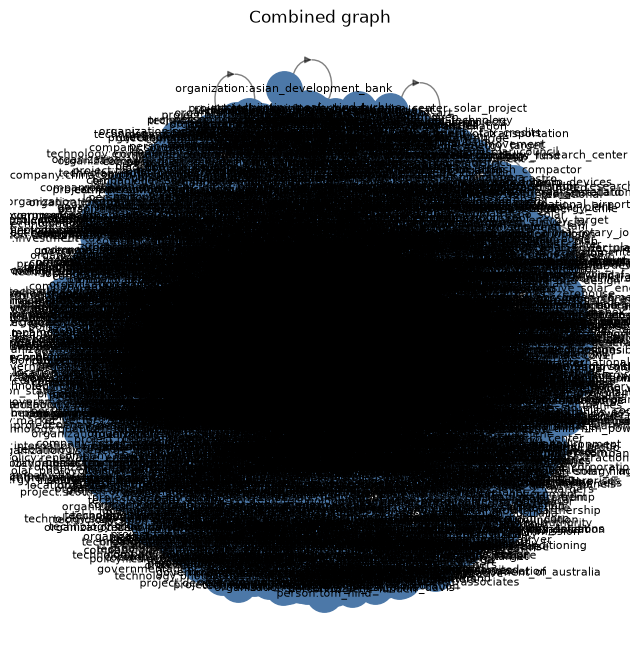

In [9]:
# Optional: also build a single combined graph for comparison.
combined_graph = nx.DiGraph()
for _, row in nodes.iterrows():
    combined_graph.add_node(row["id"], type=row.get("type", "Unknown"))
for _, row in edges.iterrows():
    combined_graph.add_edge(row["source"], row["target"])

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(combined_graph, seed=42)
nx.draw_networkx_nodes(combined_graph, pos, node_size=650, node_color="#4C78A8")
nx.draw_networkx_edges(combined_graph, pos, alpha=0.5)
nx.draw_networkx_labels(combined_graph, pos, font_size=8)
plt.title("Combined graph")
plt.axis("off")
plt.show()

In [8]:
# Build the full graph using all nodes and edges.
full_graph = nx.Graph()
for _, row in nodes.iterrows():
    full_graph.add_node(row["id"], type=row.get("type", "Unknown"), name=row.get("properties", {}).get("name") if isinstance(row.get("properties"), dict) else None)
for _, row in edges.iterrows():
    if row["source"] in full_graph and row["target"] in full_graph:
        full_graph.add_edge(row["source"], row["target"])

print(f"Full graph nodes: {full_graph.number_of_nodes()}, edges: {full_graph.number_of_edges()}")

Full graph nodes: 4002, edges: 5047


In [14]:
# Community detection using the Girvan-Newman-style greedy modularity approach.
communities = list(nx.community.greedy_modularity_communities(full_graph))
communities = [c for c in communities if len(c) > 10]
print(f"Found {len(communities)} communities")
for idx, community in enumerate(sorted(communities, key=len, reverse=True), start=1):
    print(f"Community {idx}: {len(community)} nodes")
    print(list(sorted(list(community))[:10]))

Found 31 communities
Community 1: 495 nodes
['company:accel_partners', 'company:advanced_grid_solutions', 'company:amazon', 'company:ambri', 'company:aps', 'company:arizona_diamondbacks', 'company:arizona_public_service', 'company:barclays', 'company:bechtel', 'company:best_buy']
Community 2: 437 nodes
['company:1366_technologies', 'company:aeronautica_windpower', 'company:aes', 'company:apple_computer', 'company:applied_materials', 'company:audi', 'company:black_coral_capital', 'company:bloomberg_new_energy_finance', 'company:bosch', 'company:byd']
Community 3: 403 nodes
['company:allegheny_energy', 'company:alliant_energy', 'company:alstom', 'company:altarock', 'company:american_electric_power', 'company:american_solar_king_corporation', 'company:austin_energy', 'company:berkshire_hathaway', 'company:bp', 'company:bp_technology_ventures']
Community 4: 345 nodes
['article_id', 'company:7_eleven', 'company:agl_energy', 'company:all_american_homes', 'company:american_hometec', 'company:

In [15]:
community_map = {}

for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

In [16]:
import pandas as pd
import networkx as nx

rows = []

for cid, nodes in enumerate(communities):

    subgraph = full_graph.subgraph(nodes)

    rows.append({
        "community": cid,
        "nodes": len(nodes),
        "edges": subgraph.number_of_edges(),
        "density": nx.density(subgraph),
        "avg_degree":
            sum(dict(subgraph.degree()).values()) / len(subgraph)
    })

community_df = pd.DataFrame(rows)

community_df.sort_values("nodes", ascending=False)

,community,nodes,edges,density,avg_degree
0,0,495,726,0.005938,2.933333
1,1,437,586,0.006151,2.681922
2,2,403,508,0.006271,2.521092
3,3,345,369,0.006218,2.139130
4,4,241,272,0.009405,2.257261
5,5,106,108,0.019407,2.037736
6,6,95,103,0.023068,2.168421
7,7,57,58,0.036341,2.035088
8,8,56,56,0.036364,2.000000
9,9,55,56,0.037710,2.036364


In [17]:
for cid, nodes in enumerate(communities):

    sub = full_graph.subgraph(nodes)

    top_nodes = sorted(
        sub.degree,
        key=lambda x: x[1],
        reverse=True
    )[:10]

    print(f"\nCommunity {cid}")
    print(top_nodes)


Community 0
[('company:solarcity', 105), ('company:tesla_motors', 51), ('organization:us_solar_energy_industries_association', 36), ('location:california', 35), ('company:sunrun', 33), ('policy:net_metering', 31), ('location:massachusetts', 24), ('country:united_states', 23), ('location:nevada', 19), ('location:arizona', 19)]

Community 1
[('company:first_solar', 64), ('company:sunpower_corporation', 44), ('country:china', 39), ('company:solyndra', 37), ('technology:photovoltaic_panels', 25), ('governmentagency:chinese_government', 22), ('company:suntech_power_holdings', 21), ('policy:feed_in_tariff', 20), ('governmentagency:us_department_of_commerce', 19), ('company:suntech_power', 18)]

Community 2
[('technology:solar_energy', 93), ('company:google', 28), ('company:nrg_energy_inc', 25), ('governmentagency:us_department_of_energy', 23), ('company:brightsource_energy', 21), ('person:barack_obama', 20), ('organization:international_energy_agency', 16), ('technology:wind_power', 16), ('

In [18]:
from collections import Counter

for cid, nodes in enumerate(communities):

    counts = Counter(
        full_graph.nodes[n]["type"]
        for n in nodes
    )

    print(cid, counts)

0 Counter({'Company': 122, 'Organization': 77, 'Policy': 76, 'Project': 60, 'Technology': 52, 'Location': 43, 'Person': 34, 'GovernmentAgency': 31})
1 Counter({'Company': 120, 'Project': 54, 'Policy': 50, 'Technology': 48, 'Organization': 47, 'Location': 45, 'GovernmentAgency': 38, 'Person': 34, 'Source': 1})
2 Counter({'Project': 90, 'Company': 83, 'Organization': 50, 'Policy': 46, 'Technology': 41, 'Location': 39, 'Person': 34, 'GovernmentAgency': 20})
3 Counter({'Company': 86, 'Project': 86, 'Organization': 51, 'Person': 35, 'Technology': 32, 'Location': 32, 'Policy': 14, 'GovernmentAgency': 7, 'Source': 1, 'Unknown': 1})
4 Counter({'Location': 53, 'Project': 46, 'Company': 42, 'Organization': 29, 'Technology': 24, 'Policy': 20, 'Person': 16, 'GovernmentAgency': 11})
5 Counter({'Company': 34, 'Organization': 16, 'Project': 16, 'Technology': 11, 'Policy': 10, 'Location': 9, 'Person': 6, 'GovernmentAgency': 4})
6 Counter({'Project': 41, 'Company': 18, 'Location': 15, 'Technology': 11,

In [22]:
from collections import Counter
import pandas as pd


def _node_label(node_id: str) -> str:
    props = full_graph.nodes[node_id].get("properties", {})
    if isinstance(props, dict) and props.get("name"):
        return props["name"]
    return node_id


bridge_rows = []
for u, v in full_graph.edges():
    if u not in community_map or v not in community_map:
        continue

    cu = community_map[u]
    cv = community_map[v]
    if cu == cv:
        continue

    bridge_rows.append(
        {
            "source": u,
            "target": v,
            "source_type": full_graph.nodes[u].get("type", "Unknown"),
            "target_type": full_graph.nodes[v].get("type", "Unknown"),
            "source_community": cu,
            "target_community": cv,
            "source_label": _node_label(u),
            "target_label": _node_label(v),
        }
    )

bridge_df = pd.DataFrame(bridge_rows)
print(f"Found {len(bridge_df)} inter-community edges.")

if not bridge_df.empty:
    bridge_type_pairs = (
        bridge_df.groupby(["source_type", "target_type"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    print("\nTop node-type pairs that connect communities:")
    print(bridge_type_pairs.head(15).to_string(index=False))

    bridge_nodes = pd.concat(
        [
            bridge_df[["source", "source_type", "source_community"]].rename(
                columns={"source": "node", "source_type": "node_type", "source_community": "community"}
            ),
            bridge_df[["target", "target_type", "target_community"]].rename(
                columns={"target": "node", "target_type": "node_type", "target_community": "community"}
            ),
        ],
        ignore_index=True,
    )
    bridge_nodes["label"] = bridge_nodes["node"].map(_node_label)

    bridge_node_stats = (
        bridge_nodes.groupby(["node_type", "node", "label"])
        .size()
        .reset_index(name="inter_community_links")
        .sort_values(["inter_community_links", "node_type"], ascending=[False, True])
    )
    print("\nTop bridge nodes by node type:")
    print(bridge_node_stats.head(20).to_string(index=False))

    bridge_organization_nodes = bridge_node_stats[
        bridge_node_stats["node_type"].isin(["Organization", "Policy", "GovernmentAgency", "Project"])
    ]
    print("\nMost common organization/policy/project bridge nodes:")
    print(bridge_organization_nodes.head(15).to_string(index=False))

    community_pair_summary = (
        bridge_df.groupby(["source_community", "target_community", "source_type", "target_type"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    print("\nMost frequent inter-community connector patterns:")
    print(community_pair_summary.head(20).to_string(index=False))
else:
    print("No inter-community edges were found.")

Found 775 inter-community edges.

Top node-type pairs that connect communities:
     source_type      target_type  count
         Company          Company     84
      Technology          Company     71
         Company          Project     57
         Company       Technology     48
         Company         Location     40
      Technology     Organization     35
        Location          Project     29
      Technology         Location     26
         Company           Policy     25
        Location          Company     23
      Technology GovernmentAgency     21
         Company GovernmentAgency     20
GovernmentAgency          Company     20
      Technology          Project     20
GovernmentAgency          Project     19

Top bridge nodes by node type:
       node_type                                                node                                               label  inter_community_links
      Technology                             technology:solar_panels                    

In [23]:
from itertools import combinations


pairwise_rows = []
for community_a, community_b in combinations(range(len(communities)), 2):
    pair_edges = bridge_df[
        (
            ((bridge_df["source_community"] == community_a) & (bridge_df["target_community"] == community_b))
            | ((bridge_df["source_community"] == community_b) & (bridge_df["target_community"] == community_a))
        )
    ].copy()

    if pair_edges.empty:
        pairwise_rows.append(
            {
                "community_a": community_a,
                "community_b": community_b,
                "edge_count": 0,
                "top_type_pairs": [],
                "top_bridge_node_types": [],
            }
        )
        continue

    pair_nodes = pd.concat(
        [
            pair_edges[["source", "source_type"]].rename(columns={"source": "node", "source_type": "node_type"}),
            pair_edges[["target", "target_type"]].rename(columns={"target": "node", "target_type": "node_type"}),
        ],
        ignore_index=True,
    )

    top_type_pairs = (
        pair_edges.groupby(["source_type", "target_type"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(5)
    )

    top_node_types = (
        pair_nodes.groupby("node_type")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(5)
    )

    pairwise_rows.append(
        {
            "community_a": community_a,
            "community_b": community_b,
            "edge_count": len(pair_edges),
            "top_type_pairs": top_type_pairs.to_dict("records"),
            "top_bridge_node_types": top_node_types.to_dict("records"),
        }
    )

community_pair_details = pd.DataFrame(pairwise_rows)
community_pair_details = community_pair_details.sort_values(
    ["edge_count", "community_a", "community_b"], ascending=[False, True, True]
).reset_index(drop=True)

print(f"Computed pairwise bridge summary for {len(community_pair_details)} community pairs.")
print("\nTop community pairs by bridge edge count:")
print(community_pair_details.head(25).to_string(index=False))

community_pair_matrix = pd.DataFrame(
    0,
    index=range(len(communities)),
    columns=range(len(communities)),
)

for row in community_pair_details.itertuples(index=False):
    community_pair_matrix.at[row.community_a, row.community_b] = row.edge_count
    community_pair_matrix.at[row.community_b, row.community_a] = row.edge_count

print("\nPairwise edge-count matrix (rows/columns = community index):")
print(community_pair_matrix.to_string())


Computed pairwise bridge summary for 465 community pairs.

Top community pairs by bridge edge count:
 community_a  community_b  edge_count                                                                                                                                                                                                                                                                                                                                                             top_type_pairs                                                                                                                                                                                              top_bridge_node_types
           0            2          94                      [{'source_type': 'Location', 'target_type': 'Project', 'count': 8}, {'source_type': 'Technology', 'target_type': 'Company', 'count': 7}, {'source_type': 'Company', 'target_type': 'Technology', 'count': 6}, {'source_type': 'Polic

In [19]:
community_graph = nx.Graph()

for u, v in full_graph.edges():

    if u not in community_map or v not in community_map:
        continue

    cu = community_map[u]
    cv = community_map[v]

    if cu != cv:
        if community_graph.has_edge(cu, cv):
            community_graph[cu][cv]["weight"] += 1
        else:
            community_graph.add_edge(cu, cv, weight=1)

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Visualize NetworkX Graph
# ----------------------------
def visualize_graph_improved(G):
    """
    Visualize a NetworkX graph where:
      - Node size is proportional to degree
      - Node color is based on degree
      - Force-directed layout reduces overlap
    """

    # Degree of each node
    degrees = dict(G.degree())
    degree_values = np.array(list(degrees.values()))

    # Scale node sizes
    min_size = 100
    max_size = 1500

    if degree_values.max() == degree_values.min():
        node_sizes = np.full(len(degree_values), (min_size + max_size) / 2)
    else:
        node_sizes = min_size + (
            (degree_values - degree_values.min()) /
            (degree_values.max() - degree_values.min())
        ) * (max_size - min_size)

    # Spring layout (force-directed)
    pos = nx.spring_layout(
        G,
        k=1.0 / np.sqrt(len(G.nodes())),   # Increase to spread nodes farther apart
        iterations=300,
        seed=42
    )

    plt.figure(figsize=(14, 10))

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=degree_values,
        cmap=plt.cm.viridis,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.3,
        width=1
    )

    # Optional labels (comment out for large graphs)
    if len(G.nodes()) <= 100:
        nx.draw_networkx_labels(
            G,
            pos,
            font_size=8
        )

    cbar = plt.colorbar(nodes)
    cbar.set_label("Node Degree")

    plt.title("Network Graph\n(Node Size & Color = Degree)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

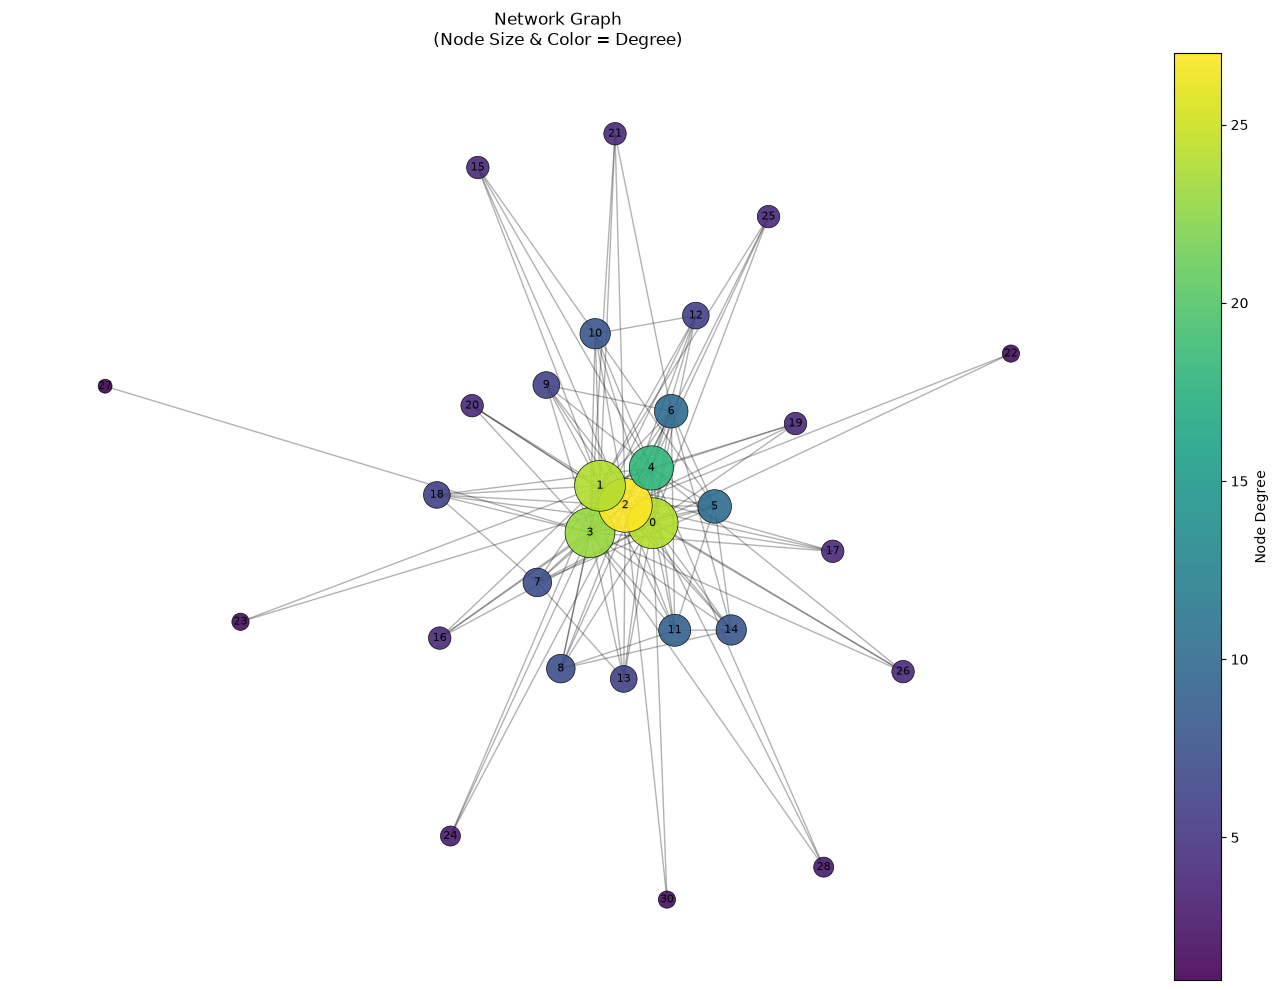

In [28]:
visualize_graph_improved(community_graph)
plt.show()

In [21]:
# Centrality metrics for nodes with degree > 3.
node_degree_cutoff = 3
high_degree_nodes = [node for node, degree in full_graph.degree() if degree > node_degree_cutoff]

betweenness = nx.betweenness_centrality(full_graph)
betweenness_top = sorted(((node, score) for node, score in betweenness.items() if node in high_degree_nodes), key=lambda x: x[1], reverse=True)

closeness = nx.closeness_centrality(full_graph)
closeness_top = sorted(((node, score) for node, score in closeness.items() if node in high_degree_nodes), key=lambda x: x[1], reverse=True)

pagerank = nx.pagerank(full_graph)
pagerank_top = sorted(((node, score) for node, score in pagerank.items() if node in high_degree_nodes), key=lambda x: x[1], reverse=True)

print(f"High-degree nodes ({node_degree_cutoff}+ edges): {len(high_degree_nodes)}")
print("Top betweenness:")
for node, score in betweenness_top[:10]:
    print(f"  {node}: {score:.4f}")
print("Top closeness:")
for node, score in closeness_top[:10]:
    print(f"  {node}: {score:.4f}")
print("Top PageRank:")
for node, score in pagerank_top[:10]:
    print(f"  {node}: {score:.4f}")

High-degree nodes (3+ edges): 515
Top betweenness:
  technology:solar_panels: 0.2207
  technology:solar_energy: 0.1113
  company:first_solar: 0.0734
  company:solarcity: 0.0709
  governmentagency:department_of_energy: 0.0488
  location:california: 0.0460
  company:tesla_motors: 0.0404
  country:china: 0.0332
  organization:us_solar_energy_industries_association: 0.0326
  company:apple: 0.0293
Top closeness:
  technology:solar_panels: 0.2832
  technology:solar_energy: 0.2720
  company:first_solar: 0.2643
  company:solarcity: 0.2598
  location:california: 0.2566
  organization:us_solar_energy_industries_association: 0.2500
  company:sunpower_corporation: 0.2483
  company:tesla_motors: 0.2477
  country:china: 0.2476
  company:solyndra: 0.2445
Top PageRank:
  technology:solar_panels: 0.0222
  technology:solar_energy: 0.0107
  company:solarcity: 0.0091
  company:first_solar: 0.0076
  company:tesla_motors: 0.0057
  governmentagency:department_of_energy: 0.0057
  company:sunpower_corporation: